### Load the RAW Preprocessed Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.inspection import permutation_importance
import joblib
import os

print("Loading raw training and testing data (keeping NaNs for HistBoost)...")
X_train = pd.read_csv('../data/X_train_clean_raw.csv')
X_test = pd.read_csv('../data/X_test_clean_raw.csv')

y_train = pd.read_csv('../data/y_train_clean.csv').values.ravel()
y_test = pd.read_csv('../data/y_test_clean.csv').values.ravel()
feature_names = X_train.columns.tolist()
clinic_names = ['Aimolipsies', 'Kardiologiki', 'Nefrologiki']

Loading raw training and testing data (keeping NaNs for HistBoost)...


### Train the HistBoost Model

In [2]:
print("Training HistGradientBoosting Classifier...")

hist_clf = HistGradientBoostingClassifier(
    max_iter=400,
    learning_rate=0.03,
    max_leaf_nodes=40,
    l2_regularization=1.5,
    min_samples_leaf=25,
    random_state=42
)

hist_clf.fit(X_train, y_train)

Training HistGradientBoosting Classifier...


,loss,'log_loss'
,learning_rate,0.03
,max_iter,400
,max_leaf_nodes,40
,max_depth,None
,min_samples_leaf,25
,l2_regularization,1.5
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'
,monotonic_cst,None


### Evaluate the Model

In [3]:
y_pred_hist = hist_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_hist)

print(f"\nHistBoost Accuracy: {accuracy:.2%}")
print("-" * 40)
print("Classification Report:")
print(classification_report(y_test, y_pred_hist, target_names=clinic_names))


HistBoost Accuracy: 66.67%
----------------------------------------
Classification Report:
              precision    recall  f1-score   support

 Aimolipsies       0.73      0.74      0.73      1567
Kardiologiki       0.72      0.66      0.69      1567
 Nefrologiki       0.56      0.60      0.58      1568

    accuracy                           0.67      4702
   macro avg       0.67      0.67      0.67      4702
weighted avg       0.67      0.67      0.67      4702



### Visualize the Confusion Matrix

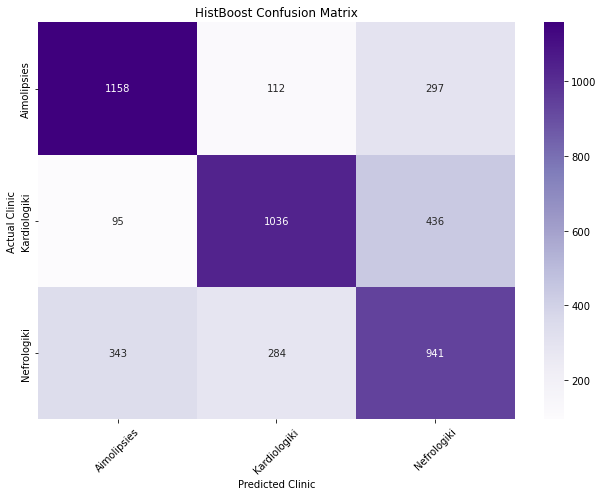

In [4]:
plt.figure(figsize=(9, 7))
sns.heatmap(confusion_matrix(y_test, y_pred_hist), annot=True, fmt='d', cmap='Purples',
            xticklabels=clinic_names, yticklabels=clinic_names)
plt.title('HistBoost Confusion Matrix')
plt.ylabel('Actual Clinic')
plt.xlabel('Predicted Clinic')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Permutation Feature Importance

Calculating Permutation Importance.


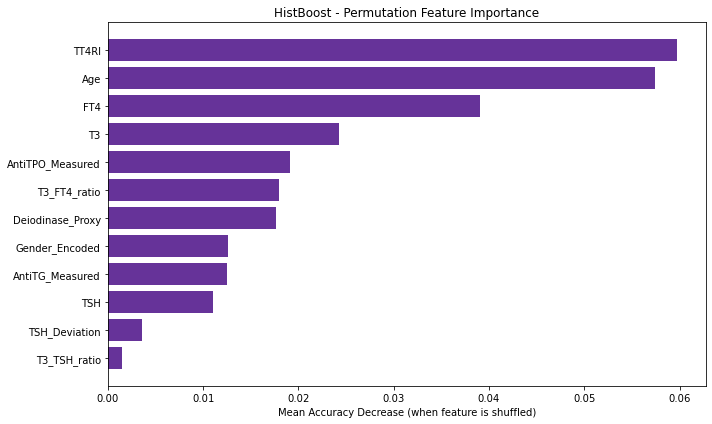

In [5]:
# Note: HistBoost doesn't have a native 'feature_importances_' attribute. 
# We use Permutation Importance.
print("Calculating Permutation Importance.")
result = permutation_importance(hist_clf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
sorted_idx = result.importances_mean.argsort()

plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), result.importances_mean[sorted_idx], color='rebeccapurple')
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
plt.title('HistBoost - Permutation Feature Importance')
plt.xlabel('Mean Accuracy Decrease (when feature is shuffled)')
plt.tight_layout()
plt.show()

### Save the Model

In [6]:
os.makedirs('models', exist_ok=True)

print("\nSaving model to 'models/histboost_model.pkl'...")
joblib.dump(hist_clf, 'models/histboost_model.pkl')
print("Model saved successfully!")


Saving model to 'models/histboost_model.pkl'...
Model saved successfully!
